In [1]:
import os
from datetime import datetime
from typing import Dict, Union
import pickle
import pandas as pd
import torch
from azureml.core import Workspace, Dataset, Datastore

In [2]:
EXPOSURE_PATH = "p1_postop/SSL/exposure/preop.csv"
OUTCOME_PATH = "p1_postop/SSL/targets/BLEED.csv"
MAPPING_PATH = "Zahra/Data-07-2025/MDP/PreMEDS/hash_to_integer_map.pkl"
DATASTORE_NAME = "researcher_data"

# Azure ML workspace configuration
SUBSCRIPTION_ID = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
RESOURCE_GROUP = 'forskerpl-n0ybkr-rg'
WORKSPACE_NAME = 'forskerpl-n0ybkr-mlw'

TIMESTAMP_COL = 'time'
ABSPOS_COL = 'abspos'
PID_COL = 'subject_id'
MANDATORY_COLUMNS = [TIMESTAMP_COL, PID_COL]


In [3]:
def get_workspace() -> Workspace:
    return Workspace(
        subscription_id=SUBSCRIPTION_ID,
        resource_group=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME
    )

# -------------------
# Load CSV from Datastore
# -------------------
def read_csv_from_datastore(
    ws: Workspace,
    datastore_name: str,
    csv_path: str,
    rename_dict: Dict[str, str] = None,
    local_dir: str = "./temp_data"
) -> pd.DataFrame:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, csv_path))
    file_paths = dataset.download(target_path=local_dir, overwrite=True)
    df = pd.read_csv(file_paths[0])
    if rename_dict:
        df = df.rename(columns=rename_dict)
    return df


# -------------------
# Load PyTorch Mapping File from Datastore
# -------------------

def load_mapping_from_datastore_file(
    ws: Workspace,
    datastore_name: str,
    file_path: str,
    local_dir: str = "./temp_data"
) -> Dict[str, int]:
    os.makedirs(local_dir, exist_ok=True)
    datastore = Datastore.get(ws, datastore_name)
    dataset = Dataset.File.from_files((datastore, file_path))
    downloaded_files = dataset.download(target_path=local_dir, overwrite=True)
    
    local_path = downloaded_files[0]
    
    with open(local_path, "rb") as f:
        mapping = pickle.load(f)
    
    return mapping
# -------------------
# Data Cleaning Utilities
# -------------------
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    if all(col in df.columns for col in MANDATORY_COLUMNS):
        df = df.dropna(subset=MANDATORY_COLUMNS, how="any")
    df = df.drop_duplicates()
    return df


def get_hours_since_epoch(timestamps: Union[pd.Series, datetime]) -> Union[pd.Series, float]:
    if isinstance(timestamps, pd.Series):
        if len(timestamps) == 0:
            return pd.Series([], dtype=float)
        timestamps = pd.to_datetime(timestamps, utc=True, errors="coerce").dt.tz_localize(None)
        seconds = timestamps.view("int64") // 10**9  # ✅ بدون اخطار در پانداس جدید
        hours = seconds / 3600
        return hours
    else:
        ts = pd.to_datetime(timestamps, utc=True).tz_localize(None)
        return (ts.value // 10**9) / 3600

def map_pids_to_ints(df: pd.DataFrame, pid_map: Dict[str, int]) -> pd.DataFrame:
    df[PID_COL] = df[PID_COL].astype(str).map(pid_map)
    df = df.dropna(subset=[PID_COL])
    df = df.copy()
    df.loc[:, PID_COL] = df[PID_COL].astype(int)
    return df


In [4]:

# -------------------
# OOT - Fine tune - 2021 - 2022
# -------------------
from datetime import datetime

def filter_by_date_range(
    df: pd.DataFrame,
    start_date: str,
    end_date: str,
    timestamp_col: str,
    name: str = "DataFrame",
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Filters the DataFrame to only include rows where timestamp_col is between start_date (inclusive)
    and end_date (exclusive). Prints useful stats if verbose=True.
    
    Args:
        df: Input DataFrame
        start_date: Start date (inclusive), in 'YYYY-MM-DD'
        end_date: End date (exclusive), in 'YYYY-MM-DD'
        timestamp_col: Name of the column containing timestamps
        name: Optional name to show in printed output
        verbose: Whether to print summary info

    Returns:
        Filtered DataFrame
    """
    df = df.copy()
    original_len = len(df)
    print(f"\n[DEBUG] {name} - Sample values in '{timestamp_col}':")
    print(df[timestamp_col].dropna().astype(str).unique()[:5])
    print(f"[DEBUG] {name} - dtype of '{timestamp_col}': {df[timestamp_col].dtype}")

    # Parse dates
    df["parsed_time"] = pd.to_datetime(df[timestamp_col], utc=True, errors="coerce")
    start = pd.to_datetime(start_date).tz_localize("UTC")
    end = pd.to_datetime(end_date).tz_localize("UTC")
    
    # Filter
    df_filtered = df[
        (df["parsed_time"] >= start) & 
        (df["parsed_time"] < end)
    ].drop(columns=["parsed_time"])

    # Verbose print
    if verbose:
        print(f"\n========== {name} Filtering Report ==========")
        print(f"Total rows before filtering: {original_len}")
        print(f"Total rows after filtering:  {len(df_filtered)}")
        print(f"Rows removed:                {original_len - len(df_filtered)}")
        if len(df_filtered) > 0:
            parsed_times = pd.to_datetime(df_filtered[timestamp_col], utc=True)
            print("\nFirst 3 timestamps after filtering:")
            print(parsed_times.sort_values().head(3).dt.strftime('%Y-%m-%d %H:%M:%S %Z'))
            print("\nLast 3 timestamps after filtering:")
            print(parsed_times.sort_values().tail(3).dt.strftime('%Y-%m-%d %H:%M:%S %Z'))
            print(f"\nDate range after filtering:")
            print(f"Min: {parsed_times.min()}")
            print(f"Max: {parsed_times.max()}")
        else:
            print("\n No data left after filtering.")

    return df_filtered

In [5]:
def plot_monthly_distribution(df, timestamp_col, title, color):
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd

    df = df.copy()
    df['month'] = pd.to_datetime(df[timestamp_col]).dt.to_period('M').dt.to_timestamp()
    monthly_counts = df['month'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(monthly_counts.index, monthly_counts.values, color=color, width=20)

    # فقط سال یا هر چند ماه یک‌بار برچسب بزن
    if len(monthly_counts) > 36:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    else:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

    ax.set_title(title)
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


In [6]:
if __name__ == "__main__":
    ws = get_workspace()

In [13]:
if __name__ == "__main__":
    # -------------------
    # Reading Data
    # -------------------
    exposure = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=EXPOSURE_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )
    print ("Exposure:",len(exposure))

    outcome = read_csv_from_datastore(
        ws,
        datastore_name=DATASTORE_NAME,
        csv_path=OUTCOME_PATH,
        rename_dict={"PID": PID_COL, "TIMESTAMP": TIMESTAMP_COL}
    )
    print ("Outcome:",len(outcome))


{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Exposure: 767161
{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}
Outcome: 20856


In [8]:
task_name = "Bleed Prediction"

print(f"Task: {task_name}")
print(f"   - Exposure data: {len(exposure):,} records from {exposure[PID_COL].nunique():,} unique patients")
print(f"   - Outcome data: {len(outcome):,} records from {outcome[PID_COL].nunique():,} unique patients")


Task: Bleed Prediction
   - Exposure data: 767,161 records from 526,364 unique patients
   - Outcome data: 20,856 records from 19,911 unique patients


In [14]:
if __name__ == "__main__":
    # -------------------
    # Clean Data
    # -------------------
    exposure = clean_data(exposure)
    outcome = clean_data(outcome)

    print(" Raw exposure TIMESTAMP samples:")
    print(exposure.head(10))
    print(exposure.dtypes)
    print ("Outcome:",len(exposure))

    print("\n Raw outcome TIMESTAMP samples:")
    print(outcome.head(10))
    print(outcome.dtypes)
    print ("Outcome:",len(outcome))


 Raw exposure TIMESTAMP samples:
                                          subject_id        time  abspos
0  88572797278B2604219A1962B005B801289909140F1CA7...  2016-05-24  -32208
1  A34E5948E6C23BDED4FCD553D0BC34649EE22759D15454...  2016-06-22  -31512
2  E8B62CFB71809D901D1F101BFE66F5EB2DD1718227E698...  2016-11-05  -28248
3  F3046580D734B72A9297A8D2F78D0C32DEFB51ED1B71E0...  2016-11-05  -28248
4  E11AAAD876434636E91090720629285F45E1F3988CA7AB...  2016-11-07  -28200
5  B8D182E9A64ABD5B53218D83FB56AA3E7DD59FC4807BA7...  2016-11-05  -28248
6  6042880BEEFBB68CF9EE07F7C6A419C65BFD5C19F28DF7...  2016-11-06  -28224
7  D12E8673ABC04698C867C8D10AACB99F68C67AA503312A...  2016-11-07  -28200
8  DBFC4230A8F61C1A4F34CA6CC9D869370591EDB3937460...  2017-05-17  -23616
9  D4F831B72C442EF0E5074E47F029E0B45655AB9563A3DF...  2016-11-08  -28176
subject_id    object
time          object
abspos         int64
dtype: object
Outcome: 767161

 Raw outcome TIMESTAMP samples:
                                      


========== STEP 5: Plot Monthly Distributions ==========


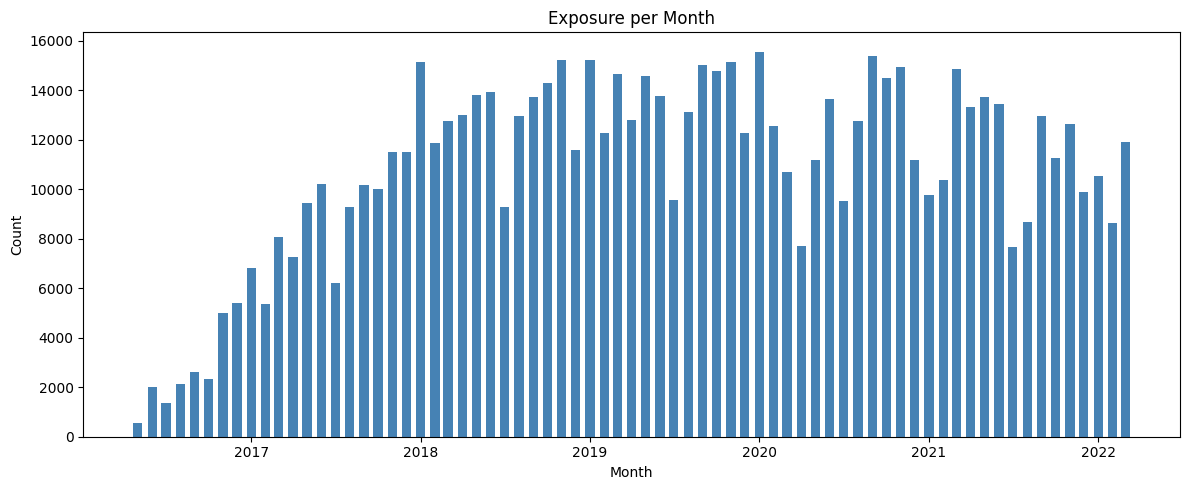

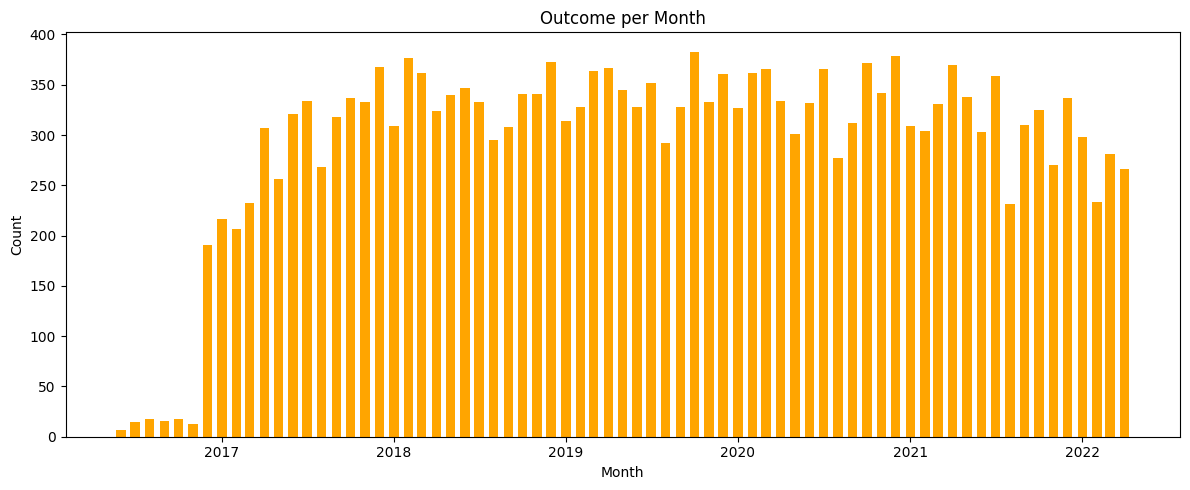

In [12]:
if __name__ == "__main__":
    ### STEP 5: Visualize Monthly Distributions
    print("\n========== STEP 5: Plot Monthly Distributions ==========")
    
    # Plot for Exposure
    plot_monthly_distribution(exposure, TIMESTAMP_COL, title="Exposure per Month", color="steelblue")

    # Plot for Outcome
    plot_monthly_distribution(outcome, TIMESTAMP_COL, title="Outcome per Month", color="orange")


In [10]:
if __name__ == "__main__":
    # -------------------
    # Load Mapping file
    # -------------------
    pid_map = load_mapping_from_datastore_file(
        ws,
        datastore_name=DATASTORE_NAME,
        file_path=MAPPING_PATH
    )


{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}


In [15]:
if __name__ == "__main__":
    ## ----------
    # OOT 
    ##----------

    # STEP 4: Time-based Filtering for OOT (2020–2021)
    print("\n========== STEP 4: Time-based Filtering (2020-01-02 to 2021-06-01) ==========")

    # فیلتر Exposure
    exposure = filter_by_date_range(
        exposure,
        start_date="2021-06-01",                   
        end_date="2022-04-1",
        timestamp_col=TIMESTAMP_COL,
        name="Exposure"
    )
    #Finetune   #       "2020-01-01"   --- "2021-06-01"
    # HoldOUt 2021-06-01   2022-04-1
    # فیلتر Outcome
    outcome_filter = filter_by_date_range(
        outcome,
        start_date="2021-06-01",
        end_date="2022-04-1",
        timestamp_col=TIMESTAMP_COL,
        name="Outcome"
    )



========== STEP 4: Time-based Filtering (2020-01-02 to 2021-06-01) ==========

[DEBUG] Exposure - Sample values in 'time':
['2016-05-24' '2016-06-22' '2016-11-05' '2016-11-07' '2016-11-06']
[DEBUG] Exposure - dtype of 'time': object

========== Exposure Filtering Report ==========
Total rows before filtering: 767161
Total rows after filtering:  107672
Rows removed:                659489

First 3 timestamps after filtering:
648418    2021-06-01 00:00:00 UTC
655983    2021-06-01 00:00:00 UTC
651370    2021-06-01 00:00:00 UTC
Name: time, dtype: object

Last 3 timestamps after filtering:
735003    2022-03-31 00:00:00 UTC
743384    2022-03-31 00:00:00 UTC
749650    2022-03-31 00:00:00 UTC
Name: time, dtype: object

Date range after filtering:
Min: 2021-06-01 00:00:00+00:00
Max: 2022-03-31 00:00:00+00:00

[DEBUG] Outcome - Sample values in 'time':
['2016-12-06' '2016-12-07' '2017-01-07' '2016-12-25' '2016-12-09']
[DEBUG] Outcome - dtype of 'time': object

========== Outcome Filtering Report


========== STEP 5: Plot Monthly Distributions ==========


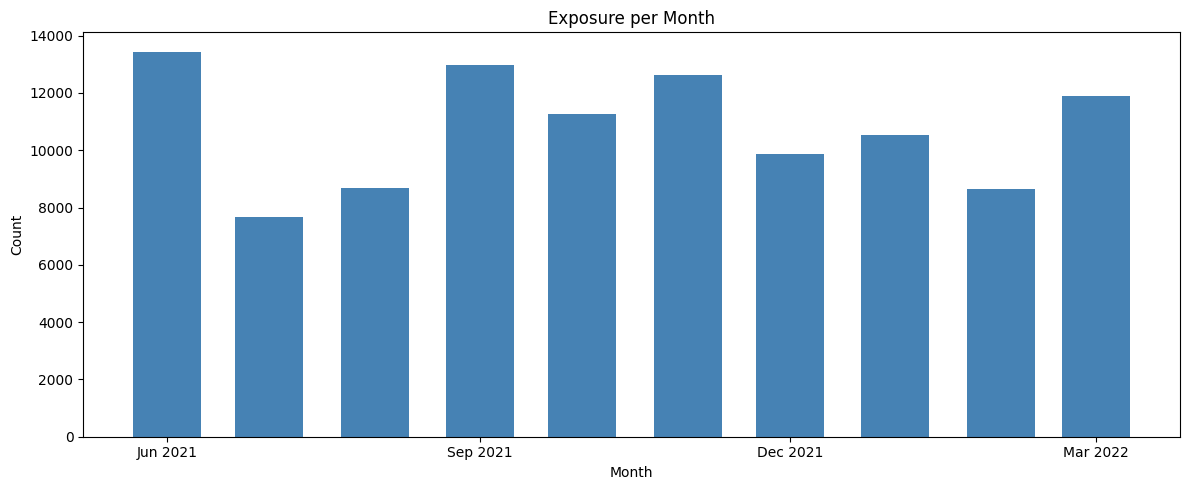

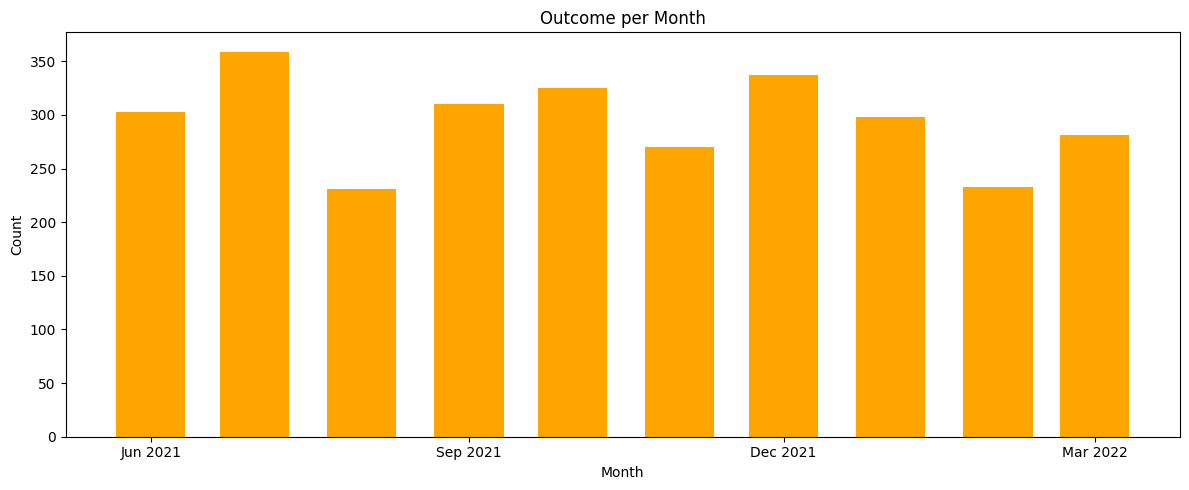

In [16]:
if __name__ == "__main__":
    ### STEP 5: Visualize Monthly Distributions
    print("\n========== STEP 5: Plot Monthly Distributions ==========")
    
    # Plot for Exposure
    plot_monthly_distribution(exposure, TIMESTAMP_COL, title="Exposure per Month", color="steelblue")

    # Plot for Outcome
    plot_monthly_distribution(outcome_filter, TIMESTAMP_COL, title="Outcome per Month", color="orange")


In [17]:
if __name__ == "__main__":
# -------------------
# Load Mapping file
# -------------------
    pid_map = load_mapping_from_datastore_file(
        ws,
        datastore_name=DATASTORE_NAME,
        file_path=MAPPING_PATH
    )
    # -------------------
# Map pids to ints
# -------------------

    exposure = map_pids_to_ints(exposure, pid_map)
    outcome = map_pids_to_ints(outcome, pid_map)

{'infer_column_types': 'False', 'activity': 'download'}
{'infer_column_types': 'False', 'activity': 'download', 'activityApp': 'FileDataset'}


/tmp/ipykernel_31035/841195042.py:75: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.loc[:, PID_COL] = df[PID_COL].astype(int)
/tmp/ipykernel_31035/841195042.py:75: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df.loc[:, PID_COL] = df[PID_COL].astype(int)


In [19]:
if __name__ == "__main__":
# -------------------
# Change Abspos col
# -------------------
    exposure[ABSPOS_COL] = get_hours_since_epoch(exposure[TIMESTAMP_COL]).astype(int)
    outcome[ABSPOS_COL] = get_hours_since_epoch(outcome[TIMESTAMP_COL]).astype(int)

    print("Exposure sample:")
    print(exposure.head())

    print("Outcome sample:")
    print(outcome.head())

Exposure sample:
       subject_id        time  abspos
16874     1854218  2021-10-01  453624
23823       84041  2021-09-27  453528
24664      173463  2021-11-19  454800
24874     1069968  2022-02-02  456600
24876      460234  2021-09-27  453528
Outcome sample:
   subject_id        time  abspos
0      741296  2016-12-06  411384
1     1312608  2016-12-07  411408
2     1858030  2016-12-07  411408
3      744497  2017-01-07  412152
4      566493  2016-12-25  411840


In [20]:
exposure.to_csv("./temp_data/exposure_Bleed_MDP.csv", index=False)
outcome.to_csv("./temp_data/outcome_Bleed_MDP.csv", index=False)

In [21]:
from azureml.core import Workspace, Datastore
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential
import os

# تنظیمات Azure ML workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

# اتصال به workspace
ws = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(ws, "researcher_data")

# استخراج اطلاعات واقعی از datastore
account_name = datastore.account_name
filesystem_name = datastore.container_name
credential = DefaultAzureCredential()

def upload_to_adls2(account_name, filesystem_name, directory_path, local_file_path, remote_file_name, credential):
    service_client = DataLakeServiceClient(account_url=f"https://{account_name}.dfs.core.windows.net", credential=credential)
    file_system_client = service_client.get_file_system_client(file_system=filesystem_name)
    directory_client = file_system_client.get_directory_client(directory_path)

    print("Uploading file")

    file_client = directory_client.create_file(remote_file_name)
    with open(local_file_path, 'rb') as file_data:
        file_contents = file_data.read()
        file_client.append_data(data=file_contents, offset=0, length=len(file_contents))
        file_client.flush_data(len(file_contents))

    print(f" File Uploaded Successfully {directory_path}/{remote_file_name}")



In [22]:

directory_path = "Zahra/CoreBehrt_OOT/MDP/4_CreateOutcome_holdout/Bleed"               # "Zahra/CoreBehrt_OOT/MDP/2_CreateOutcome/Bleed"   
# آپلود exposure
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/exposure_Bleed_MDP.csv",
    remote_file_name="exposure.csv",
    credential=credential
)

# آپلود outcome
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/outcome_Bleed_MDP.csv",
    remote_file_name="outcome.csv",
    credential=credential
)


Uploading file
 File Uploaded Successfully Zahra/CoreBehrt_OOT/MDP/4_CreateOutcome_holdout/Bleed/exposure.csv
Uploading file
 File Uploaded Successfully Zahra/CoreBehrt_OOT/MDP/4_CreateOutcome_holdout/Bleed/outcome.csv


In [29]:
common_subjects = set(exposure["subject_id"]).intersection(set(outcome["subject_id"]))
print(f"Number of bleeding patients who had any form of exposure: {len(common_subjects)}")


Number of bleeding patients who had any form of exposure: 7694


In [6]:
import pandas as pd

# فرض: exposure_df و bleed_df دو دیتافریم‌ات هستن
# 1. لیست یکتای بیمارهای exposure
exposure_patients = exposure[['subject_id']].drop_duplicates()

# 2. شمردن تعداد خونریزی برای هر subject_id که توی bleed باشه
bleed_counts = outcome['subject_id'].value_counts().reset_index()
bleed_counts.columns = ['subject_id', 'num_bleeds']

# 3. merge با exposure list تا بیماران بدون خونریزی هم بیفتن
result = exposure_patients.merge(bleed_counts, on='subject_id', how='left')

# 4. پر کردن NaN با صفر (برای کسانی که خونریزی نداشتن)
result['num_bleeds'] = result['num_bleeds'].fillna(0).astype(int)


In [6]:
result

,subject_id,num_bleeds
0,1181943,0
1,1415585,0
2,2016544,0
3,2105251,0
4,1950364,1
...,...,...
526000,651431,0
526001,214739,0
526002,1325084,0
526003,1457639,0


In [6]:
import pandas as pd

# فرض بر اینکه exposure و outcome از قبل لود شدن

# مرحله مهم: تبدیل time به datetime
exposure["time"] = pd.to_datetime(exposure["time"])
outcome["time"] = pd.to_datetime(outcome["time"])

# join
merged_df = pd.merge(exposure, outcome, on="subject_id", suffixes=('_exposure', '_outcome'))

# فیلتر فقط زمانی که خونریزی بعد از exposure بوده
merged_df = merged_df[merged_df['time_outcome'] > merged_df['time_exposure']]

# محاسبه فاصله زمانی
merged_df["days_to_bleed"] = (merged_df["time_outcome"] - merged_df["time_exposure"]).dt.days


**time_exposure**

تاریخ در معرض بودن (مثل جراحی یا شروع درمان پرخطر)

**abspos_exposure**

موقعیت زمانی نسبی (مثلاً تعداد روز از یک مبدا مثل 1 ژانویه 2000)

**time_outcome**

تاریخ وقوع outcome (در اینجا: خونریزی)


**abspos_outcome**

موقعیت زمانی نسبی outcome


**days_to_bleed**

فاصله زمانی برحسب روز بین exposure و خونریزی





In [8]:
merged_df

,subject_id,time_exposure,abspos_exposure,time_outcome,abspos_outcome,days_to_bleed
0,1950364,2016-11-07,410688,2017-09-24,418392,321
1,1950364,2017-08-25,417672,2017-09-24,418392,30
3,741296,2016-11-06,410664,2016-12-06,411384,30
4,1013257,2016-12-21,411744,2018-11-17,428448,696
5,1013257,2017-10-30,419256,2018-11-17,428448,383
...,...,...,...,...,...,...
40788,880787,2016-05-26,406728,2016-06-25,407448,30
40789,1901442,2016-05-31,406848,2016-06-30,407568,30
40790,549982,2016-08-26,408936,2016-09-25,409656,30
40791,1327051,2016-06-04,406944,2016-07-04,407664,30


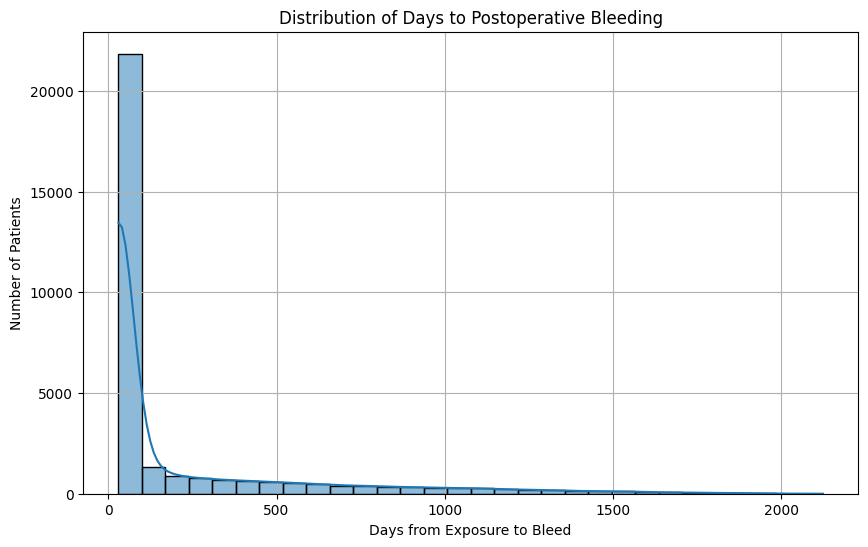

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(merged_df["days_to_bleed"], bins=30, kde=True)
plt.title("Distribution of Days to Postoperative Bleeding")
plt.xlabel("Days from Exposure to Bleed")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.show()


In [10]:
outcome_counts = merged_df.groupby("subject_id")["time_outcome"].nunique()
multi_outcome = outcome_counts[outcome_counts > 1]

print(f"Patients with multiple outcomes: {len(multi_outcome)}")
print(multi_outcome.head())


Patients with multiple outcomes: 870
subject_id
8563     2
11446    2
12372    2
15264    2
20029    2
Name: time_outcome, dtype: int64


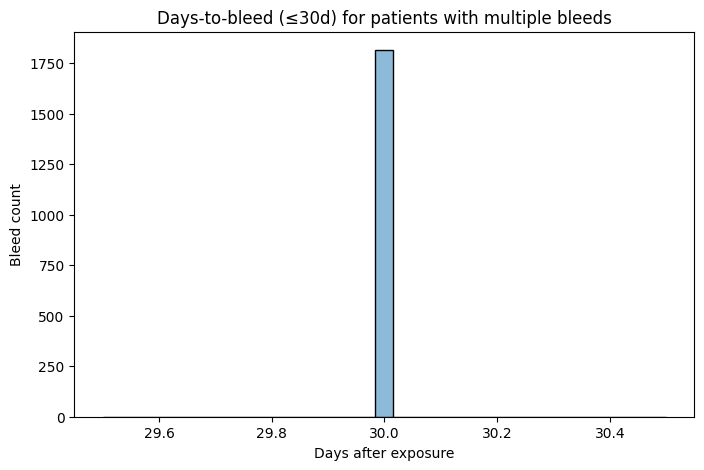

In [12]:
import seaborn as sns, matplotlib.pyplot as plt

# بیماران با بیش از یک خونریزی در ≤۳۰ روز
within_30 = merged_df[merged_df["days_to_bleed"] <= 30].copy()
bleed_counts = within_30.groupby("subject_id")["time_outcome"].nunique()
multi_ids = bleed_counts[bleed_counts > 1].index
multi_bleeds = within_30[within_30["subject_id"].isin(multi_ids)]

plt.figure(figsize=(8,5))
sns.histplot(multi_bleeds["days_to_bleed"], bins=31, kde=True)
plt.title("Days-to-bleed (≤30d) for patients with multiple bleeds")
plt.xlabel("Days after exposure"); plt.ylabel("Bleed count")
plt.show()


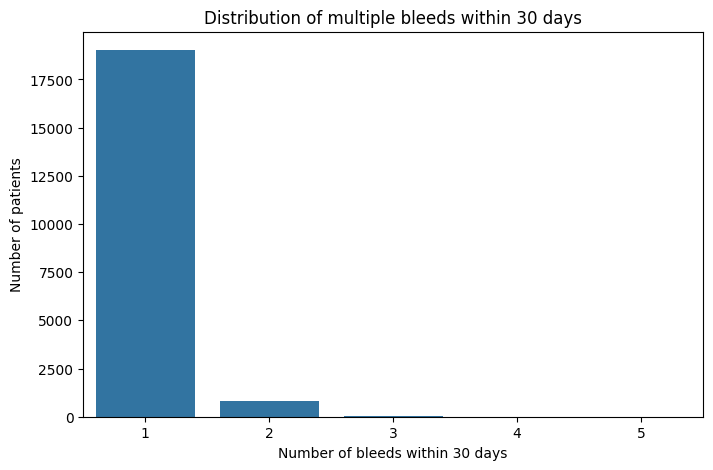

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# تعداد خونریزی ≤30 روز برای هر بیمار
bleed_counts = within_30.groupby("subject_id")["time_outcome"].nunique()

plt.figure(figsize=(8,5))
sns.countplot(x=bleed_counts.values)
plt.xlabel("Number of bleeds within 30 days")
plt.ylabel("Number of patients")
plt.title("Distribution of multiple bleeds within 30 days")
plt.show()


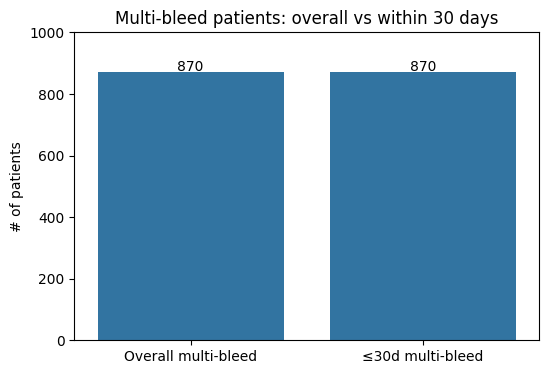

In [21]:
# کل دیتاست
overall_counts = merged_df.groupby("subject_id")["time_outcome"].nunique()
n_multi_overall = (overall_counts > 1).sum()
n_multi_30      = (bleed_counts  > 1).sum()

plt.figure(figsize=(6,4))
sns.barplot(x=["Overall multi-bleed","≤30d multi-bleed"], y=[n_multi_overall, n_multi_30])
plt.title("Multi-bleed patients: overall vs within 30 days")
for i,v in enumerate([n_multi_overall, n_multi_30]):
    plt.text(i, v+5, str(v), ha="center")
plt.ylabel("# of patients"); plt.ylim(0, max(n_multi_overall, n_multi_30)*1.15)
plt.show()


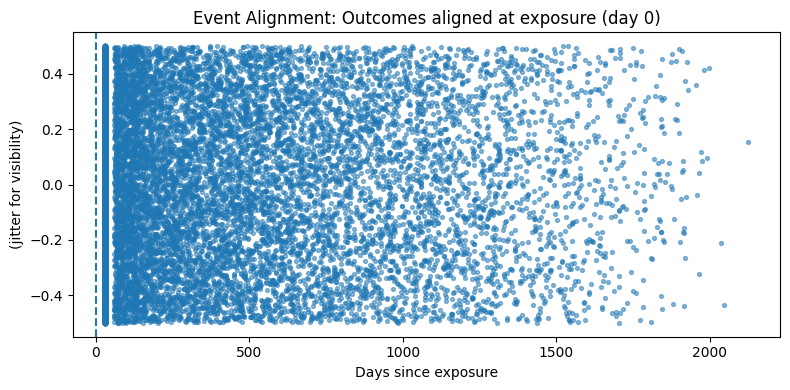

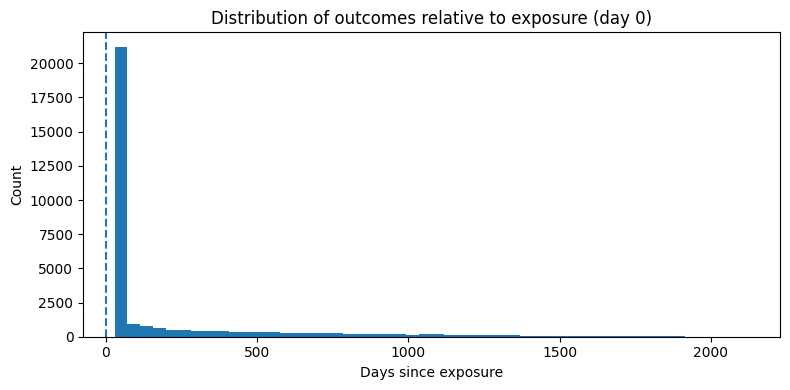

In [15]:
# محور نسبی: روز از exposure
import numpy as np
aligned = merged_df[['subject_id','time_exposure','time_outcome','days_to_bleed']].copy()
aligned['t0'] = 0  # exposure at day 0
aligned['t_outcome'] = aligned['days_to_bleed']  # روز outcome نسبت به 0

# 2a) پراکندگی همه‌ی اپیزودها (هر سطر یک نقطه روی t_outcome)
plt.figure(figsize=(8,4))
# کمی jitter عمودی صرفاً برای دیده‌شدن تراکم
y = np.random.uniform(-0.5, 0.5, size=len(aligned))
plt.scatter(aligned['t_outcome'], y, s=8, alpha=0.5)
plt.axvline(0, linestyle='--')  # day 0
plt.xlabel('Days since exposure')
plt.ylabel('(jitter for visibility)')
plt.title('Event Alignment: Outcomes aligned at exposure (day 0)')
plt.tight_layout()
plt.show()

# 2b) هیستوگرام t_outcome (یعنی همان days_to_bleed)، اما در چارچوب هم‌ترازی
plt.figure(figsize=(8,4))
plt.hist(aligned['t_outcome'], bins=50)
plt.axvline(0, linestyle='--')
plt.xlabel('Days since exposure')
plt.ylabel('Count')
plt.title('Distribution of outcomes relative to exposure (day 0)')
plt.tight_layout()
plt.show()


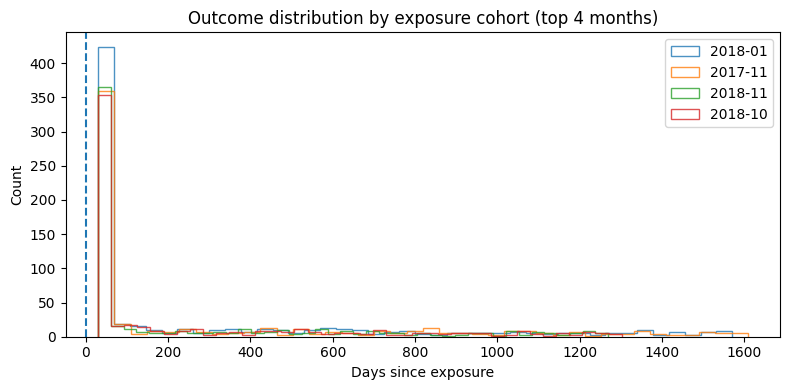

In [16]:
# کوهورت بر اساس ماهِ exposure
merged_df['exposure_month'] = merged_df['time_exposure'].dt.to_period('M').astype(str)

# میانگین یا صدک‌های days_to_bleed در هر کوهورت
summary = (merged_df.groupby('exposure_month')['days_to_bleed']
             .agg(['count','mean','median','quantile'])
             .rename(columns={'quantile':'(needs param)'}))

# یا صرفاً چند سری هیستوگرام روی هم (احتیاط: اگر گروه‌ها زیادند، شلوغ می‌شود)
cohorts = (merged_df['exposure_month'].value_counts().head(4).index)  # 4 کوهورت پرتکرار برای دید بهتر
plt.figure(figsize=(8,4))
for c in cohorts:
    plt.hist(merged_df.loc[merged_df['exposure_month']==c,'days_to_bleed'],
             bins=40, histtype='step', label=c, alpha=0.8)
plt.axvline(0, linestyle='--')
plt.xlabel('Days since exposure')
plt.ylabel('Count')
plt.title('Outcome distribution by exposure cohort (top 4 months)')
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

# فرض بر اینکه merged_df داری که شامل subject_id, time_exposure, time_outcome, days_to_bleed هست

# فقط outcome هایی که در ≤ 30 روز اتفاق افتادن
within_30 = merged_df[merged_df["days_to_bleed"] <= 30]

# شمارش تعداد خونریزی برای هر بیمار (بعد از هر exposure)
bleed_counts = within_30.groupby("subject_id")["time_outcome"].nunique()

# فقط بیمارانی که بیشتر از 1 بار خونریزی داشتن
multi_bleeders = bleed_counts[bleed_counts > 1]

print("تعداد بیماران با بیش از یک خونریزی ظرف 30 روز:", len(multi_bleeders))
print(multi_bleeders.head())

# اگر بخوای جزییات رکوردهای این بیماران رو ببینی:
patients_with_multiple_bleeds = within_30[within_30["subject_id"].isin(multi_bleeders.index)]
print(patients_with_multiple_bleeds.head(20))


تعداد بیماران با بیش از یک خونریزی ظرف 30 روز: 870
subject_id
8563     2
11446    2
12372    2
15264    2
20029    2
Name: time_outcome, dtype: int64
     subject_id time_exposure  abspos_exposure time_outcome  abspos_outcome  \
10      1430985    2017-06-16           415992   2017-07-16          416712   
13      1430985    2019-08-11           434856   2019-09-10          435576   
130      275592    2016-12-06           411384   2017-01-05          412104   
133      275592    2021-11-26           454968   2021-12-26          455688   
192     2031046    2017-11-30           420000   2017-12-30          420720   
195     2031046    2018-02-14           421824   2018-03-16          422544   
259     1563942    2016-11-16           410904   2016-12-16          411624   
263     1563942    2017-02-21           413232   2017-03-23          413952   
267     1563942    2017-05-17           415272   2017-06-16          415992   
268      697669    2016-11-30           411240   2016-12-30 

بررسی توزیع زمانی:

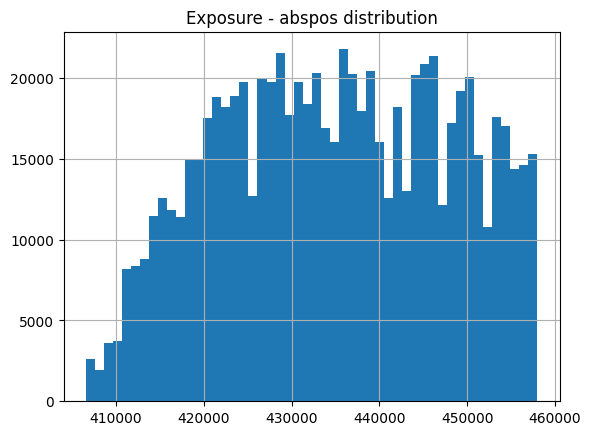

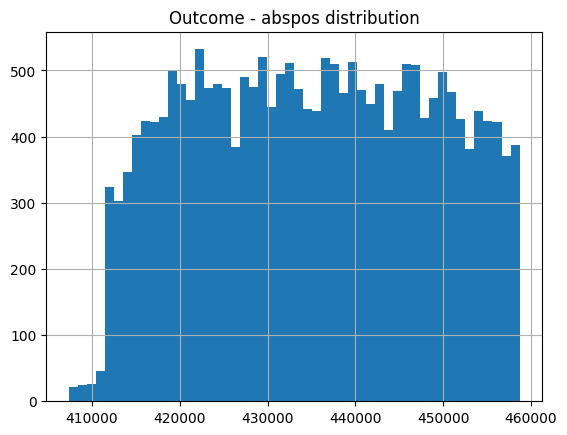

In [24]:
import matplotlib.pyplot as plt

exposure["abspos"].hist(bins=50)
plt.title("Exposure - abspos distribution")
plt.show()

outcome["abspos"].hist(bins=50)
plt.title("Outcome - abspos distribution")
plt.show()


یشتر داده‌ها در سمت چپ جمع شدن → یعنی برای بیشتر افراد، فاصله‌ی زمانی بین 

exposure و outcome 

خیلی کم بوده، مثلاً 0 تا 50 روز.

بیشترین فراوانی در بازه‌ی خیلی کوچیکه (مثلاً 0 تا 50 روز)
→ این یعنی در اکثر موارد،
 outcome خیلی سریع بعد از exposure رخ داده.

یه دُم بلند به سمت راست داریم (right skewed)

→ این یعنی بعضی افراد فاصله‌ی خیلی طولانی‌تری داشتن (مثلاً حتی تا 2000 روز = ~5.5 سال)، ولی اون‌ها تعدادشون خیلی کمه.

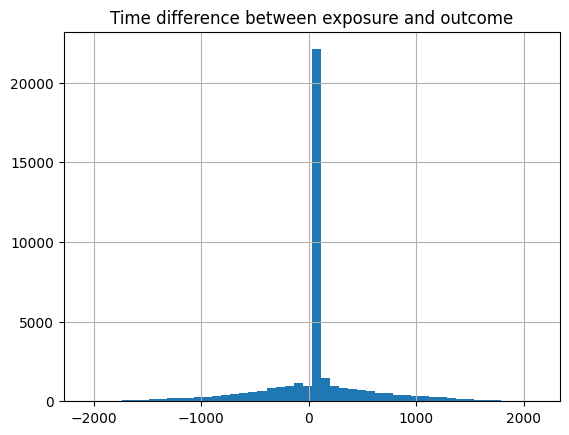

In [26]:
merged = pd.merge(exposure, outcome, on="subject_id", suffixes=("_exp", "_out"))
merged["delta_hours"] = merged["abspos_out"] - merged["abspos_exp"]
merged["delta_days"] = merged["delta_hours"] / 24
merged["delta_days"].hist(bins=50)
plt.title("Time difference between exposure and outcome")
plt.show()


بیشتر outcome

ها بلافاصله بعد از exposure

 اتفاق افتادن → احتمال وجود رابطه‌ی مستقیم یا علّی.

In [12]:
print(merged["delta_days"].value_counts().sort_index())


0.0         7
30.0    19885
Name: delta_days, dtype: int64


In [9]:
from azureml.core import Workspace, Datastore
from azure.storage.filedatalake import DataLakeServiceClient
from azure.identity import DefaultAzureCredential
import os

# تنظیمات Azure ML workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

# اتصال به workspace
ws = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(ws, "researcher_data")

# استخراج اطلاعات واقعی از datastore
account_name = datastore.account_name
filesystem_name = datastore.container_name
credential = DefaultAzureCredential()

def upload_to_adls2(account_name, filesystem_name, directory_path, local_file_path, remote_file_name, credential):
    service_client = DataLakeServiceClient(account_url=f"https://{account_name}.dfs.core.windows.net", credential=credential)
    file_system_client = service_client.get_file_system_client(file_system=filesystem_name)
    directory_client = file_system_client.get_directory_client(directory_path)

    print("Uploading file")

    file_client = directory_client.create_file(remote_file_name)
    with open(local_file_path, 'rb') as file_data:
        file_contents = file_data.read()
        file_client.append_data(data=file_contents, offset=0, length=len(file_contents))
        file_client.flush_data(len(file_contents))

    print(f" File Uploaded Successfully {directory_path}/{remote_file_name}")



In [11]:

directory_path = "Zahra/CoreBehrt/MDP/2_CreateOutcome/Bleed"

# آپلود exposure
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/exposure_Bleed_MDP.csv",
    remote_file_name="exposure.csv",
    credential=credential
)

# آپلود outcome
upload_to_adls2(
    account_name=account_name,
    filesystem_name=filesystem_name,
    directory_path=directory_path,
    local_file_path="./temp_data/outcome_Bleed_MDP.csv",
    remote_file_name="outcome.csv",
    credential=credential
)


Uploading file
 File Uploaded Successfully Zahra/CoreBehrt/MDP/2_CreateOutcome/Bleed/exposure.csv
Uploading file
 File Uploaded Successfully Zahra/CoreBehrt/MDP/2_CreateOutcome/Bleed/outcome.csv
